In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = '../data'

EXPERIMENTO_PATH = os.path.join(DATA_DIR, 'final_dataset.csv')
QUI_QUADRADO_PATH = os.path.join(DATA_DIR, 'resultado_qui_quadrado.csv')
TESTE_T_PATH = os.path.join(DATA_DIR, 'resultado_teste_t.csv')
APROVACAO_PATH = os.path.join(DATA_DIR, 'taxa_aprovacao_por_genero.csv')

df_testt = pd.read_csv(TESTE_T_PATH)
df_chisquare = pd.read_csv(QUI_QUADRADO_PATH)
df_aprovation = pd.read_csv(APROVACAO_PATH)
df_experiment = pd.read_csv(EXPERIMENTO_PATH)


In [31]:
df_experiment.describe()

,candidate_id,pair_id,score
count,300.000000,300.000000,300.000000
mean,50.500000,24.500000,7.760000
std,28.914301,14.454981,1.563291
min,1.000000,0.000000,3.000000
25%,25.750000,12.000000,7.000000
50%,50.500000,24.500000,8.000000
75%,75.250000,37.000000,9.000000
max,100.000000,49.000000,10.000000


In [32]:
df_testt.head()

,ia,n_pairs,mean_score_male,mean_score_female,mean_difference,std_difference,t_statistic,p_value,significant,interpretation
0,gemini,50,7.82,7.84,-0.02,0.2466,-0.573462,0.568954,False,No significant difference detected (α=0.05).
1,groq,50,8.32,8.24,0.08,0.3405,1.661494,0.103000,False,No significant difference detected (α=0.05).
2,openai,50,7.16,7.18,-0.02,0.1414,-1.000000,0.322223,False,No significant difference detected (α=0.05).


In [33]:
df_chisquare.head()

,ia,male_approved,male_rejected,female_approved,female_rejected,chi2_statistic,p_value,degrees_of_freedom,significant,interpretation
0,gemini,35,15,35,15,0.000000,1.000000,1,False,No significant association detected (α=0.05).
1,groq,44,6,41,9,0.313725,0.575403,1,False,No significant association detected (α=0.05).
2,openai,30,20,31,19,0.000000,1.000000,1,False,No significant association detected (α=0.05).


In [34]:
df_aprovation.head()

,ia,male_approval_pct,female_approval_pct,gap_male_minus_female
0,gemini,70.0,70.0,0.0
1,groq,88.0,82.0,6.0
2,openai,60.0,62.0,-2.0


/tmp/ipykernel_47025/708985059.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_grafico, labels=rotulos)


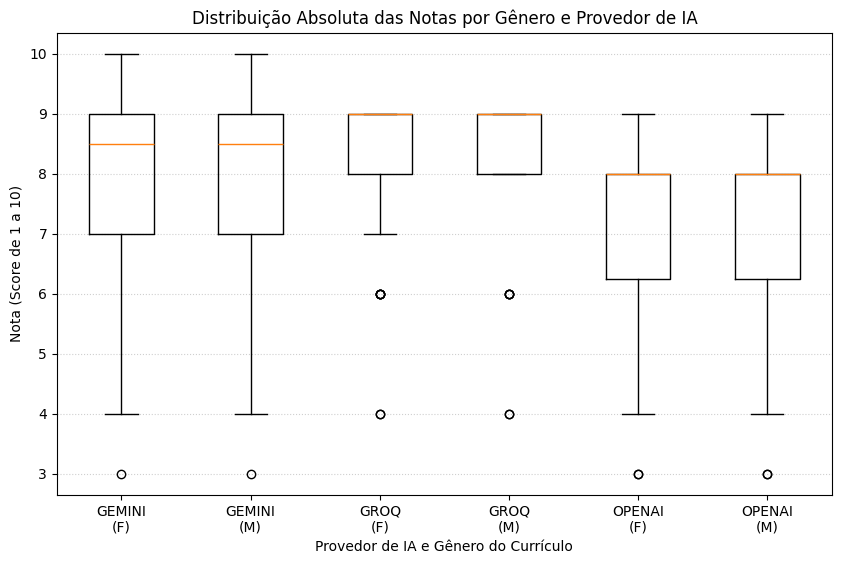

In [ ]:
dados_grafico = []
rotulos = []

ordem_ias = ['gemini', 'groq', 'openai']

for ia in ordem_ias:
    df_ia = df_experiment[df_experiment['provider'] == ia]

    generos_existentes = sorted(df_ia['gender'].unique())
    
    for g in generos_existentes:
        notas = df_ia[df_ia['gender'] == g]['score'].dropna()
        dados_grafico.append(notas)
        
        rotulos.append(f"{ia.upper()}\n({str(g).upper()})")

plt.figure(figsize=(10, 6))
plt.boxplot(dados_grafico, labels=rotulos)

plt.title('Distribuição Absoluta das Notas por Gênero e Provedor de IA')
plt.ylabel('Nota (Score de 1 a 10)')
plt.xlabel('Provedor de IA e Gênero do Currículo')
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.show()

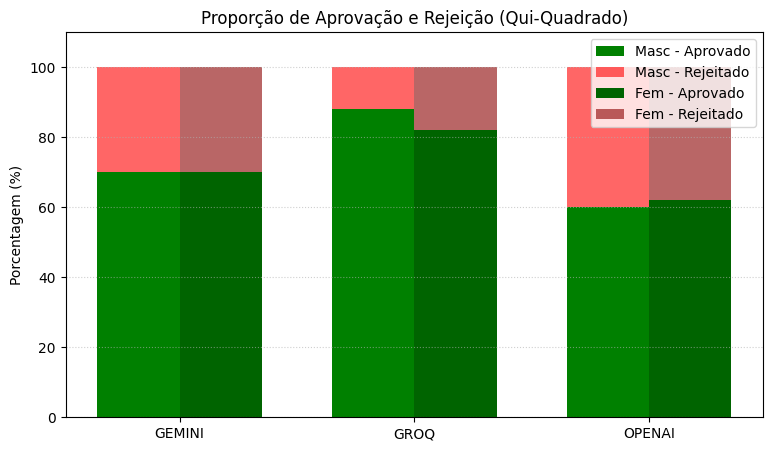

In [ ]:
ias = df_chisquare['ia'].str.upper()

total_m = df_chisquare['male_approved'] + df_chisquare['male_rejected']
total_f = df_chisquare['female_approved'] + df_chisquare['female_rejected']

aprovados_m = (df_chisquare['male_approved'] / total_m) * 100
rejeitados_m = (df_chisquare['male_rejected'] / total_m) * 100

aprovados_f = (df_chisquare['female_approved'] / total_f) * 100
rejeitados_f = (df_chisquare['female_rejected'] / total_f) * 100

x = np.arange(len(ias))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, aprovados_m, width, label='Masc - Aprovado', color='green')
plt.bar(x - width/2, rejeitados_m, width, bottom=aprovados_m, label='Masc - Rejeitado', color='red', alpha=0.6)

plt.bar(x + width/2, aprovados_f, width, label='Fem - Aprovado', color='darkgreen')
plt.bar(x + width/2, rejeitados_f, width, bottom=aprovados_f, label='Fem - Rejeitado', color='darkred', alpha=0.6)

plt.title('Proporção de Aprovação e Rejeição (Qui-Quadrado)')
plt.ylabel('Porcentagem (%)')
plt.xticks(x, ias)
plt.ylim(0, 110)
plt.legend(loc='upper right')
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()